In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
from statsmodels.tsa.statespace.varmax import VARMAXResults


In [2]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize']=15,6

In [3]:
data = "dadosIniciais.xlsx"
# Ler o arquivo Excel
data = pd.read_excel(data)

In [4]:
# Mostrar as primeiras linhas
print(data.head())

    1.137157   -0.061341    26.208588  -1.858761 
0    1.137499    0.082685   26.244322    1.471061
1    1.117805    0.225745   25.818823    4.754794
2    1.078412    0.365120   24.978243    8.000349
3    1.020086    0.498130   23.716368   11.057279
4    0.944010    0.622210   22.005617   13.972568


In [5]:
print(data.head())

    1.137157   -0.061341    26.208588  -1.858761 
0    1.137499    0.082685   26.244322    1.471061
1    1.117805    0.225745   25.818823    4.754794
2    1.078412    0.365120   24.978243    8.000349
3    1.020086    0.498130   23.716368   11.057279
4    0.944010    0.622210   22.005617   13.972568


In [6]:
df_input = pd.DataFrame()
df_input["Xreal"] = data.iloc[:, 0]
df_input["Ximg"] = data.iloc[:, 1]
df_input.head()

,Xreal,Ximg
0,1.137499,0.082685
1,1.117805,0.225745
2,1.078412,0.365120
3,1.020086,0.498130
4,0.944010,0.622210


In [7]:
df_input.head()

,Xreal,Ximg
0,1.137499,0.082685
1,1.117805,0.225745
2,1.078412,0.365120
3,1.020086,0.498130
4,0.944010,0.622210


In [8]:
df_output = pd.DataFrame()
df_output["Yreal"] = data.iloc[:, 2]
df_output["Yimg"] = data.iloc[:, 3]
df_output.head()

,Yreal,Yimg
0,26.244322,1.471061
1,25.818823,4.754794
2,24.978243,8.000349
3,23.716368,11.057279
4,22.005617,13.972568


In [9]:
df_concat = pd.concat([df_input, df_output], axis=1)
df_concat.head()

,Xreal,Ximg,Yreal,Yimg
0,1.137499,0.082685,26.244322,1.471061
1,1.117805,0.225745,25.818823,4.754794
2,1.078412,0.365120,24.978243,8.000349
3,1.020086,0.498130,23.716368,11.057279
4,0.944010,0.622210,22.005617,13.972568


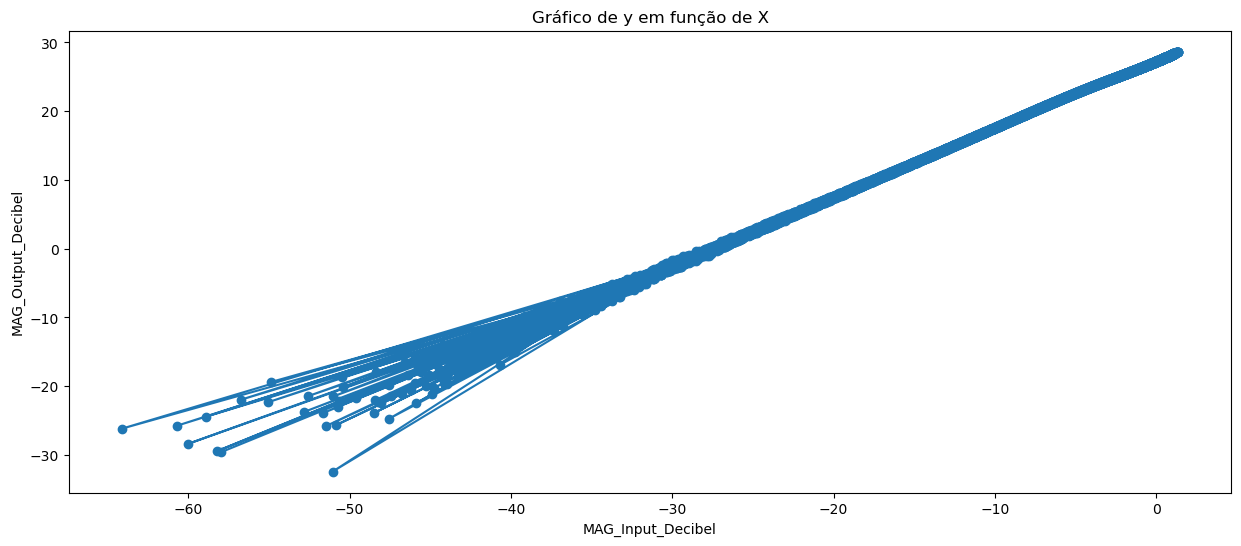

In [10]:
df_mag = pd.DataFrame()
df_mag["MAG_Input"] = np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)
df_mag["MAG_Output"] = np.sqrt(df_concat["Yreal"]**2 + df_concat["Yimg"]**2)

df_mag["MAG_Input_Decibel"]= 20 * np.log10(df_mag["MAG_Input"])
df_mag["MAG_Output_Decibel"]= 20 * np.log10(df_mag["MAG_Output"])

df_mag["MAG_Input_Decibel"]= df_mag["MAG_Input_Decibel"]
df_mag["MAG_Output_Decibel"]= df_mag["MAG_Output_Decibel"]

plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel"], marker='o')
plt.xlabel('MAG_Input_Decibel')
plt.ylabel('MAG_Output_Decibel')
plt.title('Gráfico de y em função de X')
plt.show()

In [11]:
final_res_lag_9 = VARMAXResults.load('final_res_lag_9.pkl')


FileNotFoundError: [Errno 2] No such file or directory: 'final_res_lag_9.pkl'

In [197]:
final_res_lag_9_total = VARMAXResults.load('final_res_lag_9_total.pkl')


SystemError: deallocated bytearray object has exported buffers

MemoryError: 

In [13]:
final_res_lag_2_total =  VARMAXResults.load('final_res_lag_2_total.pkl')

In [14]:
final_res_lag_2_total.params

intercept.Yreal       -0.000428
intercept.Yimg        -0.000175
L1.Yreal.Yreal         1.922533
L1.Yimg.Yreal         -0.229321
L2.Yreal.Yreal        -0.929806
L2.Yimg.Yreal          0.221805
L1.Yreal.Yimg          0.233116
L1.Yimg.Yimg           1.938340
L2.Yreal.Yimg         -0.226302
L2.Yimg.Yimg          -0.945259
beta.Xreal.Yreal       0.438828
beta.Ximg.Yreal        0.065270
beta.Xreal.Yimg       -0.096427
beta.Ximg.Yimg         0.438786
sqrt.var.Yreal         0.052468
sqrt.cov.Yreal.Yimg    0.003570
sqrt.var.Yimg          0.054643
dtype: float64

In [18]:
endog_cols=('Yreal','Yimg')
exog_cols=('Xreal','Ximg')
endog_total = df_concat[list(endog_cols)]
exog_total = df_concat[list(exog_cols)]
forecast_todos_dados_lag_2_total = final_res_lag_2_total.forecast(steps=len(exog_total), exog=exog_total)
forecast_todos_dados_lag_2_total.index = endog_total.index

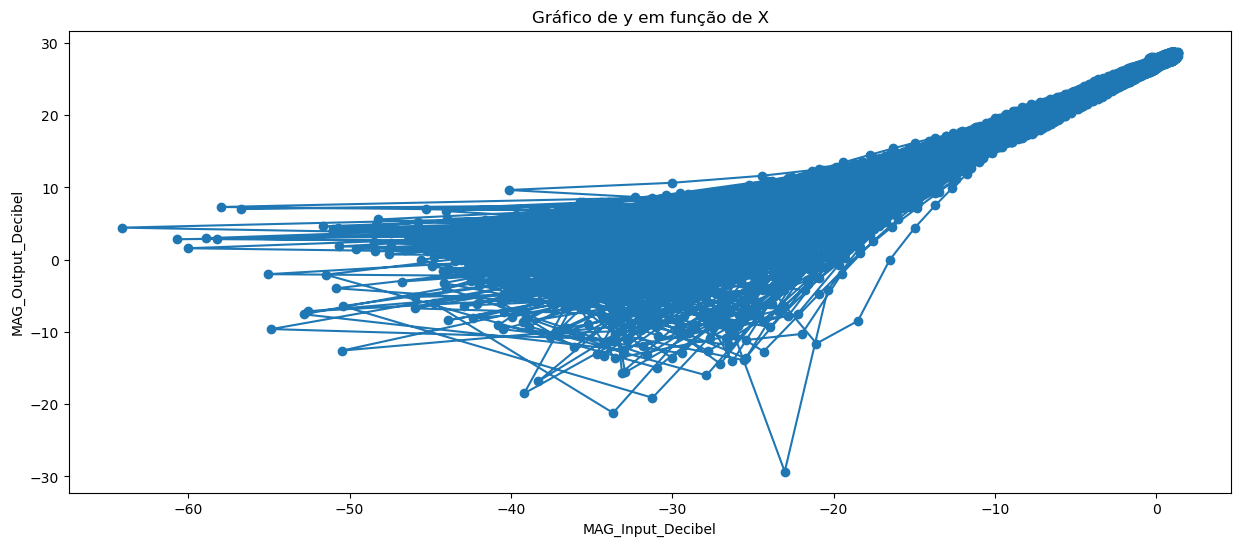

In [19]:
df_mag = pd.DataFrame()
df_mag["MAG_Input"] = np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)
df_mag["MAG_Output"] = np.sqrt(forecast_todos_dados_lag_2_total["Yreal"]**2 + forecast_todos_dados_lag_2_total["Yimg"]**2)

df_mag["MAG_Input_Decibel"]= 20 * np.log10(df_mag["MAG_Input"])
df_mag["MAG_Output_Decibel"]= 20 * np.log10(df_mag["MAG_Output"])

df_mag["MAG_Input_Decibel"]= df_mag["MAG_Input_Decibel"]
df_mag["MAG_Output_Decibel"]= df_mag["MAG_Output_Decibel"]

plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel"], marker='o')
plt.xlabel('MAG_Input_Decibel')
plt.ylabel('MAG_Output_Decibel')
plt.title('Gráfico de y em função de X')
plt.show()

In [176]:
final_res_lag_12_inverted  = VARMAXResults.load("forecast_test_lag_12_inverted.pkl")

In [177]:
final_res_lag_9.params

intercept.Yreal       -0.000169
intercept.Yimg         0.000480
L1.Yreal.Yreal         1.223752
L1.Yimg.Yreal         -0.062058
L2.Yreal.Yreal         0.154691
L2.Yimg.Yreal         -0.092091
L3.Yreal.Yreal         0.140430
L3.Yimg.Yreal          0.085064
L4.Yreal.Yreal        -0.578435
L4.Yimg.Yreal          0.146144
L5.Yreal.Yreal        -0.023775
L5.Yimg.Yreal          0.069060
L6.Yreal.Yreal        -0.261317
L6.Yimg.Yreal         -0.078078
L7.Yreal.Yreal         0.334314
L7.Yimg.Yreal         -0.186776
L8.Yreal.Yreal        -0.010854
L8.Yimg.Yreal         -0.133880
L9.Yreal.Yreal         0.027653
L9.Yimg.Yreal          0.230924
L1.Yreal.Yimg          0.041448
L1.Yimg.Yimg           1.197018
L2.Yreal.Yimg          0.113060
L2.Yimg.Yimg           0.174999
L3.Yreal.Yimg         -0.062180
L3.Yimg.Yimg           0.168131
L4.Yreal.Yimg         -0.142172
L4.Yimg.Yimg          -0.570228
L5.Yreal.Yimg         -0.089596
L5.Yimg.Yimg          -0.013518
L6.Yreal.Yimg          0.048807
L6.Yimg.

In [178]:
final_res_lag_12_inverted.params

intercept.Xreal       -0.000016
intercept.Ximg         0.000002
L1.Xreal.Xreal         1.068951
L1.Ximg.Xreal         -0.128511
L2.Xreal.Xreal         0.165460
L2.Ximg.Xreal         -0.058433
L3.Xreal.Xreal         0.172460
L3.Ximg.Xreal         -0.018300
L4.Xreal.Xreal        -0.278022
L4.Ximg.Xreal          0.067673
L5.Xreal.Xreal         0.004962
L5.Ximg.Xreal          0.085244
L6.Xreal.Xreal        -0.217949
L6.Ximg.Xreal          0.080501
L7.Xreal.Xreal         0.100795
L7.Ximg.Xreal          0.019692
L8.Xreal.Xreal        -0.094582
L8.Ximg.Xreal         -0.010871
L9.Xreal.Xreal         0.120466
L9.Ximg.Xreal         -0.061045
L10.Xreal.Xreal       -0.061673
L10.Ximg.Xreal        -0.013784
L11.Xreal.Xreal        0.077402
L11.Ximg.Xreal        -0.009878
L12.Xreal.Xreal       -0.041581
L12.Ximg.Xreal         0.033883
L1.Xreal.Ximg          0.126349
L1.Ximg.Ximg           1.075911
L2.Xreal.Ximg          0.063164
L2.Ximg.Ximg           0.188435
L3.Xreal.Ximg          0.010573
L3.Ximg.

### Predizendo o X_pré_distorcido

In [179]:
#endog_cols=('Yreal','Yimg')
exog_cols=('Xreal','Ximg')
#endog_total = df_concat[list(endog_cols)]
exog_total = df_concat[list(exog_cols)]
forecast_todos_dados_lag_12_inverted = final_res_lag_12_inverted.forecast(steps=len(exog_total), exog=exog_total)
forecast_todos_dados_lag_12_inverted.index = endog_total.index

In [180]:
forecast_todos_dados_lag_12_inverted.head()

,Xreal,Ximg
0,1.091926,-0.078766
1,1.067425,0.062149
2,1.019979,0.195983
3,0.946722,0.318624
4,0.855029,0.424912


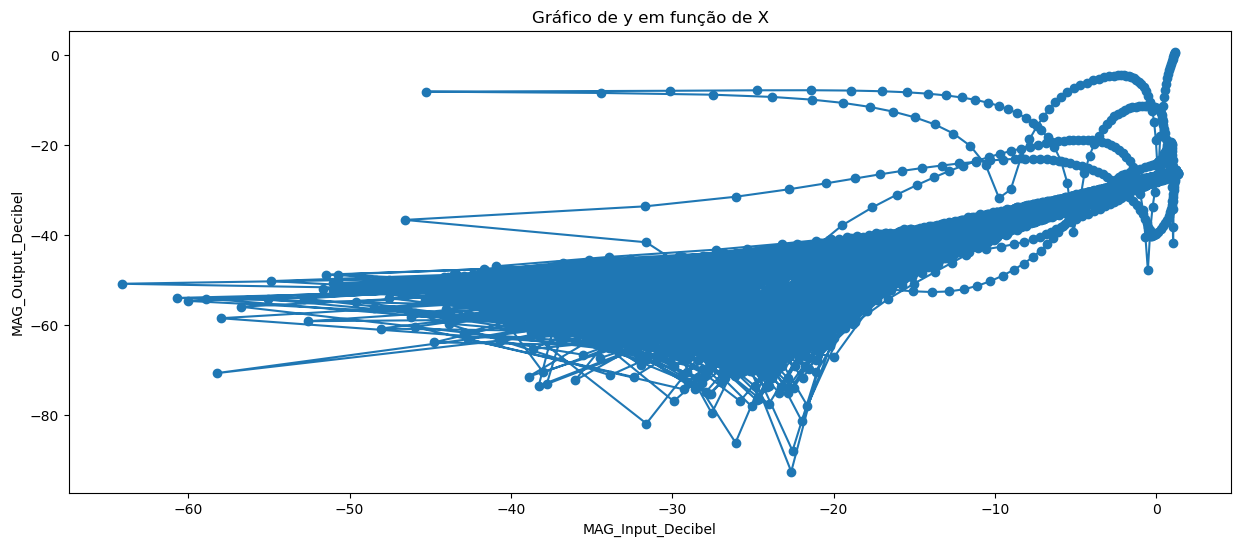

In [181]:
df_mag = pd.DataFrame()
df_mag["MAG_Input"] = np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)
df_mag["MAG_Output"] = np.sqrt(forecast_todos_dados_lag_12_inverted["Xreal"]**2 + forecast_todos_dados_lag_12_inverted["Ximg"]**2)

df_mag["MAG_Input_Decibel"]= 20 * np.log10(df_mag["MAG_Input"])
df_mag["MAG_Output_Decibel"]= 20 * np.log10(df_mag["MAG_Output"])

df_mag["MAG_Input_Decibel"]= df_mag["MAG_Input_Decibel"]
df_mag["MAG_Output_Decibel"]= df_mag["MAG_Output_Decibel"]

plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel"], marker='o')
plt.xlabel('MAG_Input_Decibel')
plt.ylabel('MAG_Output_Decibel')
plt.title('Gráfico de y em função de X')
plt.show()

### Colocando o X pré-distorcido no PA

In [182]:
#endog_cols=('Yreal','Yimg')
exog_cols=('Xreal','Ximg')
#endog_total = forecast_todos_dados_lag_5_inverted[list(endog_cols)]
exog_total = forecast_todos_dados_lag_12_inverted[list(exog_cols)]
forecast_todos_dados_lag_9_inverted = final_res_lag_9.forecast(steps=len(exog_total), exog=exog_total)
forecast_todos_dados_lag_9_inverted.index = endog_total.index

In [183]:
forecast_todos_dados_lag_9_inverted.head()

,Yreal,Yimg
0,25.586217,-2.450404
1,25.625397,0.829993
2,25.204721,4.099799
3,24.356761,7.262646
4,23.080738,10.265783


In [184]:
df_concat.head()

,Xreal,Ximg,Yreal,Yimg
0,1.137499,0.082685,26.244322,1.471061
1,1.117805,0.225745,25.818823,4.754794
2,1.078412,0.365120,24.978243,8.000349
3,1.020086,0.498130,23.716368,11.057279
4,0.944010,0.622210,22.005617,13.972568


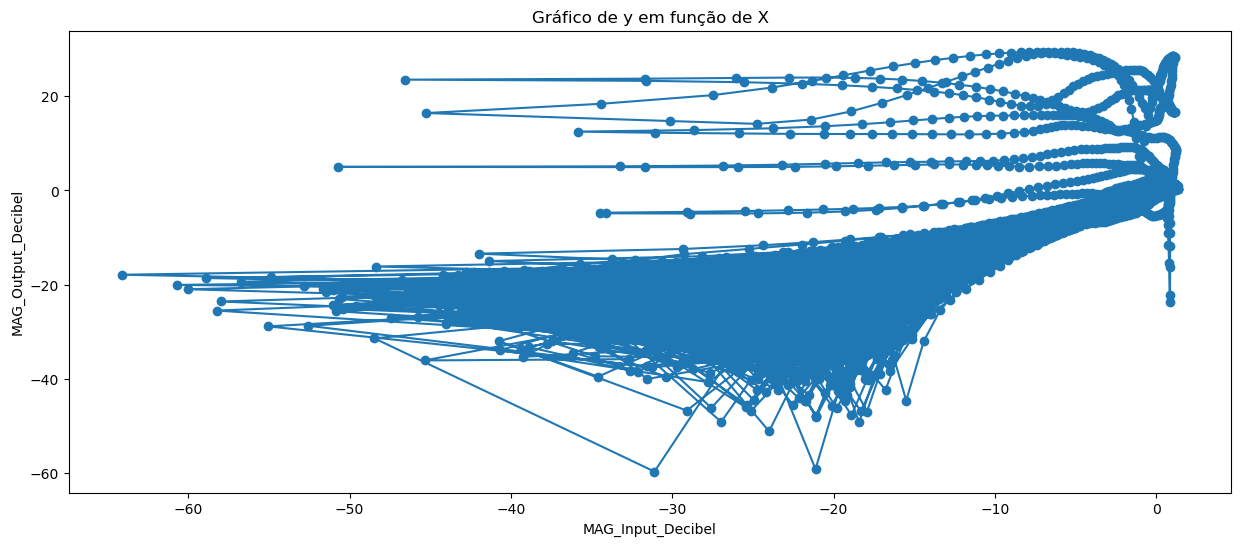

In [185]:
df_mag = pd.DataFrame()
df_mag["MAG_Input"] = np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)
df_mag["MAG_Output"] = np.sqrt(forecast_todos_dados_lag_9_inverted["Yreal"]**2 + forecast_todos_dados_lag_9_inverted["Yimg"]**2)

df_mag["MAG_Input_Decibel"]= 20 * np.log10(df_mag["MAG_Input"])
df_mag["MAG_Output_Decibel"]= 20 * np.log10(df_mag["MAG_Output"])

df_mag["MAG_Input_Decibel"]= df_mag["MAG_Input_Decibel"]
df_mag["MAG_Output_Decibel"]= df_mag["MAG_Output_Decibel"]

plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel"], marker='o')
plt.xlabel('MAG_Input_Decibel')
plt.ylabel('MAG_Output_Decibel')
plt.title('Gráfico de y em função de X')
plt.show()